In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Lasso, LassoCV, Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

In [3]:
df = pd.read_csv('spotify_dataset.csv')
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [4]:
# drop useless columns
df = df.drop(columns=['Unnamed: 0', 'track_id', 'track_name', 'album_name', 'artists'])

# convert explicit to int
df['explicit'] = df['explicit'].astype(int)

# Drop na rows
df = df.dropna()

# Define target
y = df['popularity']

# base numeric features
base_features = [
    'danceability', 'energy', 'tempo', 'valence',
    'loudness', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'duration_ms',
    'explicit'
]

X = df[base_features]

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [45]:
# Baseline linear regression
baseline_model = LinearRegression()
baseline_model.fit(X_train_scaled, y_train)

y_pred_baseline = baseline_model.predict(X_test_scaled)
#calculate mse
errors = y_test - y_pred_baseline
squared_errors = errors ** 2
mse = np.mean(squared_errors)

from sklearn.metrics import mean_squared_error, r2_score

print("BASELINE MODEL")
print("MSE:", mse)
print("R^2:", r2_score(y_test, y_pred_baseline))

BASELINE MODEL
MSE: 482.56331837335676
R^2: 0.022123586187390742


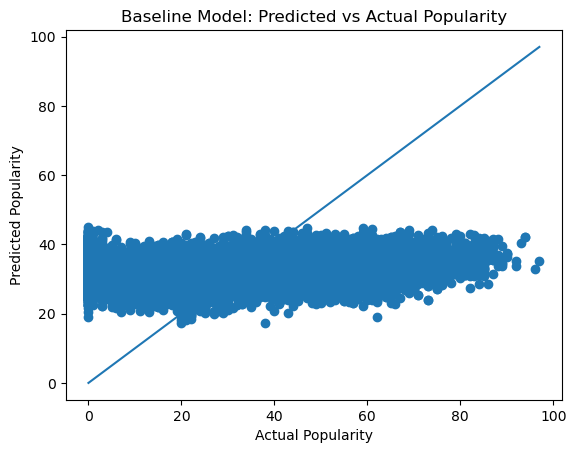

In [46]:
import matplotlib.pyplot as plt
plt.figure()
plt.scatter(y_test, y_pred_baseline)
# Perfect prediction line
min_val = min(y_test.min(), y_pred_baseline.min())
max_val = max(y_test.max(), y_pred_baseline.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")
plt.title("Baseline Model: Predicted vs Actual Popularity")

plt.show()

In [47]:
#adding poly and interaction features
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

In [48]:
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

y_pred_poly = poly_model.predict(X_test_poly)

print("POLY MODEL")
print("MSE:", mean_squared_error(y_test, y_pred_poly))
print("R^2:", r2_score(y_test, y_pred_poly))
feature_names = poly.get_feature_names_out(base_features)
print(feature_names)

POLY MODEL
MSE: 464.73888315173946
R^2: 0.058243394985755925
['danceability' 'energy' 'tempo' 'valence' 'loudness' 'speechiness'
 'acousticness' 'instrumentalness' 'liveness' 'duration_ms' 'explicit'
 'danceability^2' 'danceability energy' 'danceability tempo'
 'danceability valence' 'danceability loudness' 'danceability speechiness'
 'danceability acousticness' 'danceability instrumentalness'
 'danceability liveness' 'danceability duration_ms'
 'danceability explicit' 'energy^2' 'energy tempo' 'energy valence'
 'energy loudness' 'energy speechiness' 'energy acousticness'
 'energy instrumentalness' 'energy liveness' 'energy duration_ms'
 'energy explicit' 'tempo^2' 'tempo valence' 'tempo loudness'
 'tempo speechiness' 'tempo acousticness' 'tempo instrumentalness'
 'tempo liveness' 'tempo duration_ms' 'tempo explicit' 'valence^2'
 'valence loudness' 'valence speechiness' 'valence acousticness'
 'valence instrumentalness' 'valence liveness' 'valence duration_ms'
 'valence explicit' 'loud

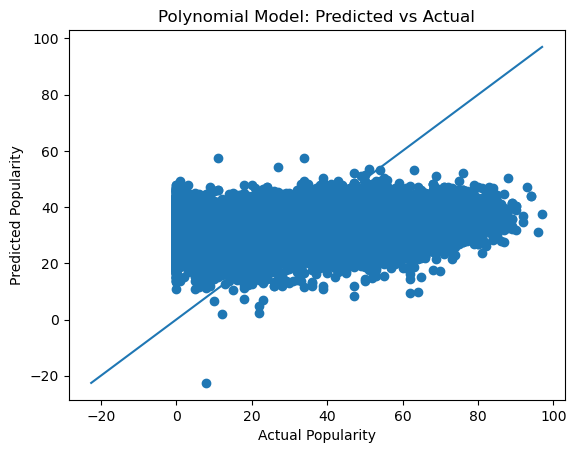

In [49]:
plt.figure()

plt.scatter(y_test, y_pred_poly)

min_val = min(y_test.min(), y_pred_poly.min())
max_val = max(y_test.max(), y_pred_poly.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")
plt.title("Polynomial Model: Predicted vs Actual")
plt.show()

In [50]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_train_poly, y_train)

y_pred_lasso = lasso.predict(X_test_poly)

print("LASSO MODEL")
print("Alpha:", lasso.alpha_)
print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("R^2:", r2_score(y_test, y_pred_lasso))

LASSO MODEL
Alpha: 0.005790019963667833
MSE: 464.75752322983436
R^2: 0.05820562234115856


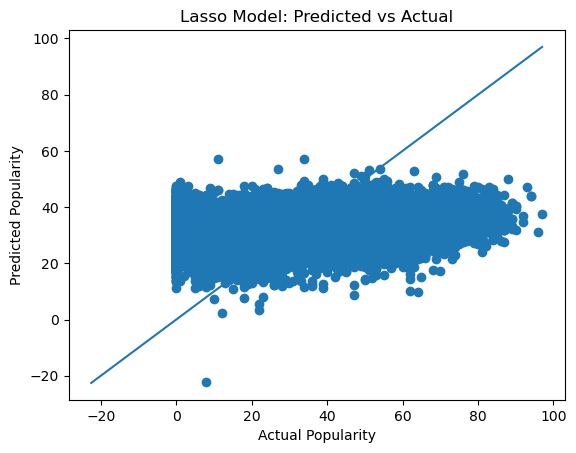

In [51]:
plt.figure()

plt.scatter(y_test, y_pred_lasso)

plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")
plt.title("Lasso Model: Predicted vs Actual")

plt.show()

In [53]:
from sklearn.linear_model import RidgeCV
import numpy as np
alphas = np.logspace(-3, 3, 50)

ridge = RidgeCV(alphas=alphas, cv=5)
ridge.fit(X_train_poly, y_train)

y_pred_ridge = ridge.predict(X_test_poly)

print("\nRIDGE MODEL")
print("Best alpha:", ridge.alpha_)
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("R^2:", r2_score(y_test, y_pred_ridge))


RIDGE MODEL
Best alpha: 568.9866029018293
MSE: 464.73342704761626
R^2: 0.05825445134940854


In [54]:
# No matter what we do, the "one model fits all" assumption, as we expected, does not work at all, since the highest R^2 we got is around 0.058, 
# now we're going to move onto stage 2 of our project, splitting the data into genres and building separate models for each genre, which we expect to perform much better.